In [1]:
import sys
import os

# Clear path overrides and append parent project root directory
sys.path.append(os.path.abspath(os.path.join('..')))

from src.data_loader import InsuranceDataLoader

# Instantiate and fire pipeline execution
loader = InsuranceDataLoader(file_path="../data/MachineLearningRating_v3.txt")
df = loader.load_and_initialize()

print(f"✅ Success! Data Matrix Loaded.")
print(f"Dimensions: {df.shape[0]:,} records available across {df.shape[1]} unique columns.")
print(f"\nAvailable Features:\n{list(df.columns)}")

✅ Success! Data Matrix Loaded.
Dimensions: 1,000,098 records available across 54 unique columns.

Available Features:
['UnderwrittenCoverID', 'PolicyID', 'TransactionMonth', 'IsVATRegistered', 'Citizenship', 'LegalType', 'Title', 'Language', 'Bank', 'AccountType', 'MaritalStatus', 'Gender', 'Country', 'Province', 'PostalCode', 'MainCrestaZone', 'SubCrestaZone', 'ItemType', 'mmcode', 'VehicleType', 'RegistrationYear', 'make', 'Model', 'Cylinders', 'cubiccapacity', 'kilowatts', 'bodytype', 'NumberOfDoors', 'VehicleIntroDate', 'CustomValueEstimate', 'AlarmImmobiliser', 'TrackingDevice', 'CapitalOutstanding', 'NewVehicle', 'WrittenOff', 'Rebuilt', 'Converted', 'CrossBorder', 'NumberOfVehiclesInFleet', 'SumInsured', 'TermFrequency', 'CalculatedPremiumPerTerm', 'ExcessSelected', 'CoverCategory', 'CoverType', 'CoverGroup', 'Section', 'Product', 'StatutoryClass', 'StatutoryRiskType', 'TotalPremium', 'TotalClaims', 'Loss_Ratio', 'Margin']


In [2]:
# Calculate absolute total metrics for AlphaCare's portfolio
total_premium_pool = df['TotalPremium'].sum()
total_claims_pool = df['TotalClaims'].sum()
global_loss_ratio = total_claims_pool / total_premium_pool

print(f"🎯 Overall Portfolio Loss Ratio: {global_loss_ratio:.4f} ({round(global_loss_ratio * 100, 2)}%)\n")

# Variations across required underwriting dimensions
for feature in ['Province', 'VehicleType', 'Gender']:
    print(f"=== Dynamic Loss Ratio Analysis by: {feature} ===")
    summary = df.groupby(feature).agg(
        Premium_Volume=('TotalPremium', 'sum'),
        Claims_Volume=('TotalClaims', 'sum')
    ).reset_index()
    
    # Calculate segment specific loss ratios safely
    summary['Loss_Ratio'] = summary['Claims_Volume'] / summary['Premium_Volume']
    print(summary.sort_values(by='Loss_Ratio', ascending=False)[df.columns[df.columns.isin([feature, 'Loss_Ratio'])]].to_string(index=False))
    print("\n" + "="*40 + "\n")

🎯 Overall Portfolio Loss Ratio: 1.0477 (104.77%)

=== Dynamic Loss Ratio Analysis by: Province ===
     Province  Loss_Ratio
      Gauteng    1.222018
KwaZulu-Natal    1.082693
 Western Cape    1.059472
   North West    0.790367
   Mpumalanga    0.720897
   Free State    0.680758
      Limpopo    0.661199
 Eastern Cape    0.633813
Northern Cape    0.282699


=== Dynamic Loss Ratio Analysis by: VehicleType ===
      VehicleType  Loss_Ratio
 Heavy Commercial    1.628112
Medium Commercial    1.050251
Passenger Vehicle    1.048198
 Light Commercial    0.232066
              Bus    0.137292


=== Dynamic Loss Ratio Analysis by: Gender ===
       Gender  Loss_Ratio
Not specified    1.059311
         Male    0.883910
       Female    0.821879




📊 Processing Outlier Boxplot for Total Claims...


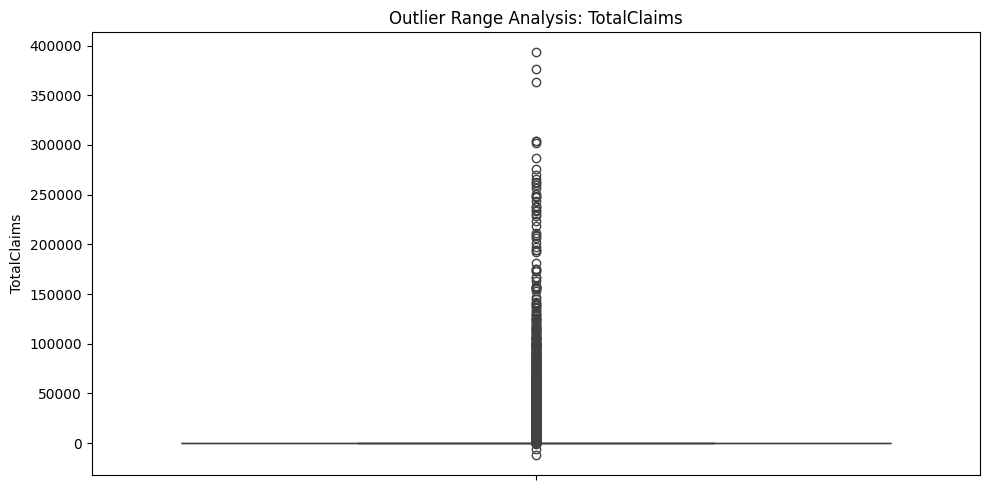

📊 Processing Outlier Boxplot for Vehicle Custom Values...


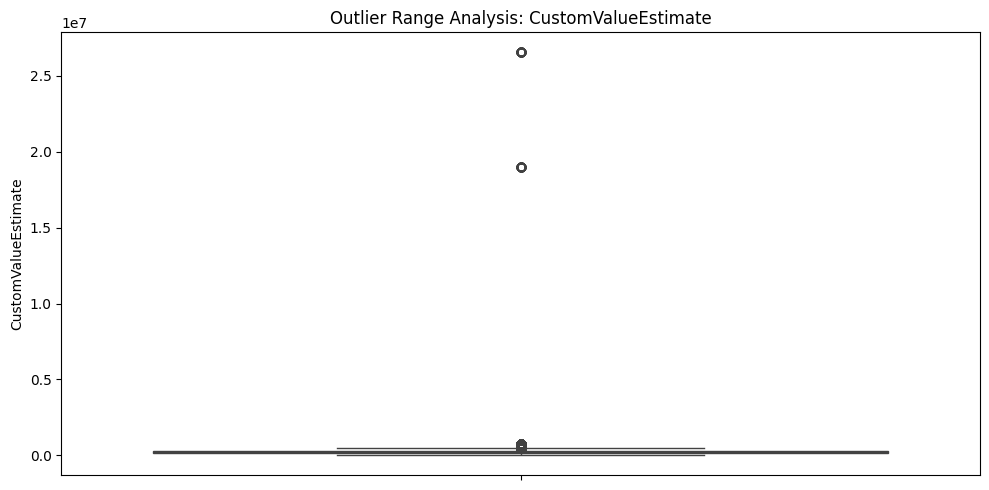

In [3]:
from src.eda_utils import InsuranceEDAVisualizer

# Instantiate the visual engine
visualizer = InsuranceEDAVisualizer()

# 1. Investigate Claim Payout outliers
print("📊 Processing Outlier Boxplot for Total Claims...")
visualizer.plot_outlier_boxplots(df, column='TotalClaims')

# 2. Investigate Vehicle Valuation outliers
print("📊 Processing Outlier Boxplot for Vehicle Custom Values...")
visualizer.plot_outlier_boxplots(df, column='CustomValueEstimate')

In [4]:
# Extract chronological time brackets
df['YearMonth'] = df['TransactionMonth'].dt.to_period('M')

# Group temporal operational matrices
temporal_summary = df.groupby('YearMonth').agg(
    Active_Policies=('PolicyID', 'count'),
    Total_Claims_Paid=('TotalClaims', 'sum'),
    Claim_Frequency=('TotalClaims', lambda x: (x > 0).mean()), # % of policies with claims
    Claim_Severity=('TotalClaims', lambda x: x[x > 0].mean())   # Avg claim size when it happens
).reset_index()

print("📈 18-Month Chronological Insurance Risk Log:")
print(temporal_summary.to_string(index=False))

📈 18-Month Chronological Insurance Risk Log:
YearMonth  Active_Policies  Total_Claims_Paid  Claim_Frequency  Claim_Severity
  2013-10               45       0.000000e+00         0.000000             NaN
  2013-11             1196       5.058508e+04         0.001672    25292.539474
  2013-12             1495       9.283386e+03         0.002007     3094.461988
  2014-01             1827       1.243686e+04         0.001095     6218.429825
  2014-02             2062       6.298931e+04         0.002910    10498.217836
  2014-03             3466       3.227850e+05         0.003462    26898.751798
  2014-04             6919       3.068636e+05         0.002891    15343.179605
  2014-05             9484       5.180427e+05         0.002952    18513.253095
  2014-06            11822       5.045364e+05         0.002368    18019.157018
  2014-07            14907       4.289822e+05         0.001811    15911.766699
  2014-08            19626       6.934197e+05         0.002599    13831.806330
  2014-

In [6]:
# Group vehicle records
asset_risk = df.groupby(['make', 'Model']).agg(
    Aggregate_Claims=('TotalClaims', 'sum'),
    Total_Incidents=('TotalClaims', lambda x: (x > 0).sum()),
    Mean_Severity=('TotalClaims', lambda x: x[x > 0].mean())
).reset_index()

# Filter for a sample size of at least 15 incidents to remove one-off anomalies
credible_assets = asset_risk[asset_risk['Total_Incidents'] >= 15]

print("🚨 TOP 5 HIGHEST EXPERIMENTAL CLAIM EXPOSURE VEHICLES:")
print(credible_assets.sort_values(by='Aggregate_Claims', ascending=False).head(5).to_string(index=False))

print("\n💎 BOTTOM 5 LOWEST EXPERIMENTAL CLAIM EXPOSURE VEHICLES:")
print(credible_assets.sort_values(by='Aggregate_Claims', ascending=True).head(5).to_string(index=False))

🚨 TOP 5 HIGHEST EXPERIMENTAL CLAIM EXPOSURE VEHICLES:
  make                          Model  Aggregate_Claims  Total_Incidents  Mean_Severity
TOYOTA      QUANTUM 2.7 SESFIKILE 16s      1.203750e+07              500   24099.011847
TOYOTA      QUANTUM 2.7 SESFIKILE 15s      1.151173e+07              574   20065.200200
TOYOTA      QUANTUM 2.7 SESFIKILE 14s      9.967764e+06              454   21956.827741
TOYOTA QUANTUM 2.5 D-4D SESFIKILE 16s      7.733236e+06              266   29072.315308
TOYOTA          HiACE SUPER 16 F/Lift      3.275205e+06              173   18931.820223

💎 BOTTOM 5 LOWEST EXPERIMENTAL CLAIM EXPOSURE VEHICLES:
  make                          Model  Aggregate_Claims  Total_Incidents  Mean_Severity
TOYOTA                  AVANZA 1.3 SX     291370.588947               15   19424.705930
TOYOTA       COROLLA 1.3 PROFESSIONAL     294750.535088               18   16375.029727
JINBEI                     HAISE 2.2i     340789.587719               22   15490.435805
TOYOTA QU